# 02 — The K-Fold Family

> **All About Cross-Validation**, Notebook 2 of 4.
> *Which splitting scheme fits my data?*

Notebook 01 settled the ground rules: evaluate on unseen data, never leak, average over folds,
default to K = 5–10. Now we meet the actual **splitters** scikit-learn gives you and the job
each one is built for:

| Splitter | One-line job |
|----------|--------------|
| `KFold` | the plain baseline — rotate K equal chunks |
| `StratifiedKFold` | keep each fold's class balance equal to the whole (**classification default**) |
| `RepeatedStratifiedKFold` | repeat the whole thing with new shuffles to pin down the mean |
| `ShuffleSplit` / `StratifiedShuffleSplit` | Monte-Carlo CV — pick your own test size and number of rounds |
| `LeaveOneOut` / `LeavePOut` | extreme K — every row (or pair) gets its own turn as the test set |

Plus two things you *do* with folds beyond scoring: **out-of-fold predictions**
(`cross_val_predict`) and **cross-validation for a regression target**.

We use two datasets: **German Credit** (classification, from NB01) and **Bike Sharing**
(17k hourly rows, a real regression target `count`).

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, time
import matplotlib.pyplot as plt, seaborn as sns
%matplotlib inline
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 5)
RS = 42

from cv_datasets import load_credit, load_bike, feature_types
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

X, y = load_credit()
num_cols, cat_cols = feature_types(X)

# Same leak-proof pipeline pattern as NB01: preprocessing lives INSIDE the estimator.
def clf_pipeline():
    pre = ColumnTransformer([("num", StandardScaler(), num_cols),
                             ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)])
    return Pipeline([("pre", pre),
                     ("rf", RandomForestClassifier(n_estimators=200, random_state=RS, n_jobs=-1))])

print(f"German Credit: {X.shape}, positive rate {y.mean():.0%}")

German Credit: (1000, 20), positive rate 30%


## Section 1 — `KFold` vs `StratifiedKFold`: why stratify?

Plain `KFold` slices the data into K contiguous chunks (after an optional shuffle). If the
rows happen to be **ordered by the target** — which happens constantly in real exports sorted
by label, date, or region — some folds end up with almost none of the minority class. You then
"validate" a fraud model on a fold with zero fraud.

`StratifiedKFold` fixes this by making **every fold carry the same class proportions as the
full dataset**. Let's force the worst case by sorting the data by target, then compare.

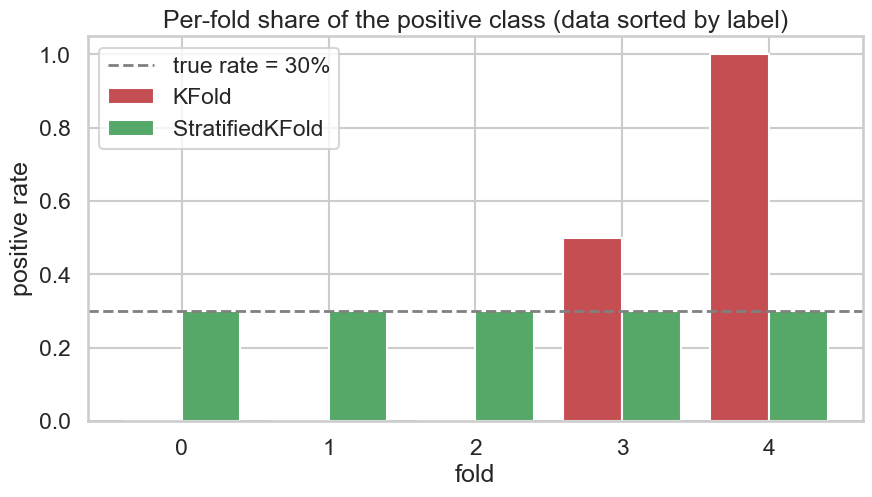

KFold per-fold positive rate : [0.  0.  0.  0.5 1. ]  std=0.400
Stratified per-fold pos rate : [0.3 0.3 0.3 0.3 0.3]  std=0.000


In [2]:
from sklearn.model_selection import KFold, StratifiedKFold

# Worst case: data arrives sorted by the label (all 'good' then all 'bad').
order = np.argsort(y.values)
X_sorted, y_sorted = X.iloc[order], y.iloc[order]

def fold_positive_rates(splitter, Xd, yd):
    return [yd.iloc[te].mean() for _, te in splitter.split(Xd, yd)]

kf_rates  = fold_positive_rates(KFold(5), X_sorted, y_sorted)
skf_rates = fold_positive_rates(StratifiedKFold(5), X_sorted, y_sorted)

fig, ax = plt.subplots(figsize=(10, 5))
xpos = np.arange(5)
ax.bar(xpos - 0.2, kf_rates, 0.4, label="KFold", color="#C44E52")
ax.bar(xpos + 0.2, skf_rates, 0.4, label="StratifiedKFold", color="#55A868")
ax.axhline(y.mean(), ls="--", color="gray", lw=2, label=f"true rate = {y.mean():.0%}")
ax.set(title="Per-fold share of the positive class (data sorted by label)",
       xlabel="fold", ylabel="positive rate", xticks=xpos)
ax.legend()
plt.show()

print("KFold per-fold positive rate :", np.round(kf_rates, 2), f" std={np.std(kf_rates):.3f}")
print("Stratified per-fold pos rate :", np.round(skf_rates, 2), f" std={np.std(skf_rates):.3f}")

### How to read this chart

- **Red (`KFold`)** is a disaster on sorted data: folds swing from **0% positives to 100%**.
  Three folds have no `bad` applicants at all, so any metric on them is meaningless — and the
  averaged score is garbage.
- **Green (`StratifiedKFold`)** pins every fold to the true ~30% rate (std ≈ 0).
- Even when data *looks* shuffled, stratification costs nothing and removes a silent failure
  mode. **For classification, `StratifiedKFold` is the default — always.**

## Section 2 — `RepeatedStratifiedKFold`: nail down the mean

A single 5-fold run still depends on *one* random partition. Shuffle differently and the mean
moves a little. **Repeated** CV runs the whole K-fold procedure several times with different
shuffles and pools all the scores — so the averaged estimate stops depending on any one lucky
partition. Below: 10 separate single-5-fold means (each a valid "result") vs one
`RepeatedStratifiedKFold(5 × 10)`.

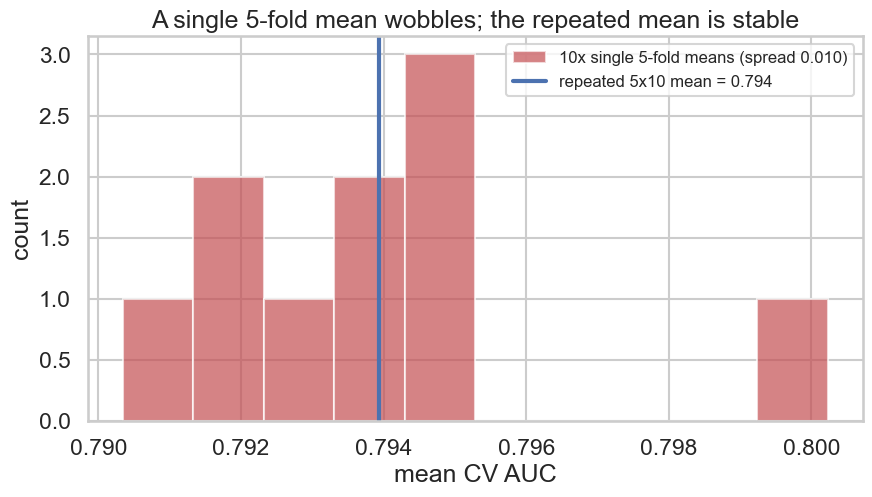

Single 5-fold means range over : 0.790 - 0.800
Repeated 5x10 : mean 0.794, standard error of the mean 0.0041 (n=50)


In [3]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

# Ten independent single-5-fold runs -> ten different "official" means.
single_means = [cross_val_score(clf_pipeline(), X, y,
                    cv=StratifiedKFold(5, shuffle=True, random_state=s), scoring="roc_auc").mean()
                for s in range(10)]

# One repeated run: 5 folds x 10 repeats = 50 scores pooled.
rep = cross_val_score(clf_pipeline(), X, y,
        cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=RS), scoring="roc_auc")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(single_means, bins=10, color="#C44E52", alpha=0.7,
        label=f"10x single 5-fold means (spread {max(single_means)-min(single_means):.3f})")
ax.axvline(rep.mean(), color="#4C72B0", lw=3,
           label=f"repeated 5x10 mean = {rep.mean():.3f}")
ax.set(title="A single 5-fold mean wobbles; the repeated mean is stable",
       xlabel="mean CV AUC", ylabel="count"); ax.legend(fontsize=12)
plt.show()

se = rep.std(ddof=1) / np.sqrt(len(rep))
print(f"Single 5-fold means range over : {min(single_means):.3f} - {max(single_means):.3f}")
print(f"Repeated 5x10 : mean {rep.mean():.3f}, standard error of the mean {se:.4f} (n=50)")

### How to read this chart

- The **red histogram** shows that "run 5-fold CV and report the mean" lands anywhere across a
  visible band, purely from which shuffle you drew.
- The **blue line** is the repeated estimate: by averaging 50 scores across 10 partitions, its
  mean barely moves run to run, and you get an honest **standard error**.
- Use repeated CV when a **decision hinges on small score differences** (model A vs B, or a
  paper/report), especially on small datasets. The cost is linear in `n_repeats`.

## Section 3 — `ShuffleSplit`: Monte-Carlo cross-validation

`KFold` ties two things together: the number of iterations **and** the test size (K folds ⇒
1/K test each). `ShuffleSplit` unties them — you independently choose **how many** random
splits and **how big** each test set is. Test sets are drawn independently, so (unlike K-fold)
they **can overlap** and don't perfectly tile the data.

In [4]:
from sklearn.model_selection import StratifiedShuffleSplit

# 20 random 80/20 splits -> 20 scores, test size decoupled from iteration count.
ss = StratifiedShuffleSplit(n_splits=20, test_size=0.20, random_state=RS)
ss_scores = cross_val_score(clf_pipeline(), X, y, cv=ss, scoring="roc_auc")
skf_scores = cross_val_score(clf_pipeline(), X, y,
                             cv=StratifiedKFold(5, shuffle=True, random_state=RS), scoring="roc_auc")

print(f"StratifiedShuffleSplit (20 x 20% test): mean {ss_scores.mean():.3f}  std {ss_scores.std():.3f}")
print(f"StratifiedKFold (5-fold)              : mean {skf_scores.mean():.3f}  std {skf_scores.std():.3f}")
print("\nKey difference: ShuffleSplit's 20 test sets are drawn independently and OVERLAP;")
print("KFold's 5 test sets are disjoint and together cover every row exactly once.")

StratifiedShuffleSplit (20 x 20% test): mean 0.785  std 0.030
StratifiedKFold (5-fold)              : mean 0.787  std 0.018

Key difference: ShuffleSplit's 20 test sets are drawn independently and OVERLAP;
KFold's 5 test sets are disjoint and together cover every row exactly once.


### How to read this

- **Use `ShuffleSplit` when** you want many repetitions but a *small* test fraction (large
  datasets), or you need a specific train/test ratio that K-fold's 1/K can't give.
- **Caveat:** because test sets overlap and some rows may be tested many times (others never),
  it is a looser estimator than K-fold. For most tabular work, `StratifiedKFold` /
  `RepeatedStratifiedKFold` is the safer default; reach for `ShuffleSplit` when you specifically
  need to decouple test size from the number of rounds.

## Section 4 — `LeaveOneOut`: the extreme end of K

**Leave-One-Out CV (LOOCV)** is just K-fold taken to its limit: **K = n**. Each single row
takes a turn as the test set while the model trains on the other n−1. For 1,000 applicants that
is 1,000 model fits.

Two things people wrongly believe about LOOCV — let's test both:
1. *"It's the most accurate CV."* It's nearly **unbiased** (trains on almost all the data) but
   has **high variance** and each per-row score is just 0 or 1.
2. *"It's worth the cost."* We'll see it lands essentially where cheap 10-fold already was.

In [5]:
from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import LogisticRegression

# Use a fast linear model — LOOCV means n fits, so the estimator must be cheap.
def linear_pipeline():
    pre = ColumnTransformer([("num", StandardScaler(), num_cols),
                             ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)])
    return Pipeline([("pre", pre), ("lr", LogisticRegression(max_iter=1000))])

t0 = time.time()
loo = cross_val_score(linear_pipeline(), X, y, cv=LeaveOneOut(), scoring="accuracy")
loo_time = time.time() - t0
tenfold = cross_val_score(linear_pipeline(), X, y,
                          cv=StratifiedKFold(10, shuffle=True, random_state=RS), scoring="accuracy")

print(f"LOOCV   : accuracy {loo.mean():.3f}   ({len(loo)} model fits, {loo_time:.0f}s)")
print(f"10-fold : accuracy {tenfold.mean():.3f}   (10 model fits, ~1s)")
print(f"\nSame answer to 3 decimals, ~{len(loo)//10}x the compute. LOOCV is extreme K, not magic.")

# LeavePOut is combinatorial: choosing p=2 test rows out of n is n*(n-1)/2 splits.
from math import comb
print(f"\nLeavePOut(p=2) on n=1000 would need {comb(1000, 2):,} splits — why nobody runs it at scale.")

LOOCV   : accuracy 0.755   (1000 model fits, 47s)
10-fold : accuracy 0.752   (10 model fits, ~1s)

Same answer to 3 decimals, ~100x the compute. LOOCV is extreme K, not magic.

LeavePOut(p=2) on n=1000 would need 499,500 splits — why nobody runs it at scale.


### How to read this

- **LOOCV ≈ 10-fold** here — the near-unbiased extreme estimate agrees with cheap 10-fold, at
  ~100× the cost. That's the usual outcome.
- **When LOOCV actually helps:** tiny datasets (dozens of rows) where you cannot spare *any*
  data for a test fold. Otherwise its high variance + cost make 5/10-fold the better tool.
- `LeavePOut` is almost never run — the number of splits explodes combinatorially. It's in the
  family for completeness, not for daily use.

## Section 5 — Out-of-fold predictions with `cross_val_predict`

`cross_val_score` hands you *scores*. Sometimes you want the actual **predictions** for every
row, each made by a model that did **not** train on that row — **out-of-fold (OOF)**
predictions. OOF predictions are the foundation of **stacking** (NB in the supervised repo) and
**probability calibration**, and they let you build an honest confusion matrix / ROC over the
whole dataset.

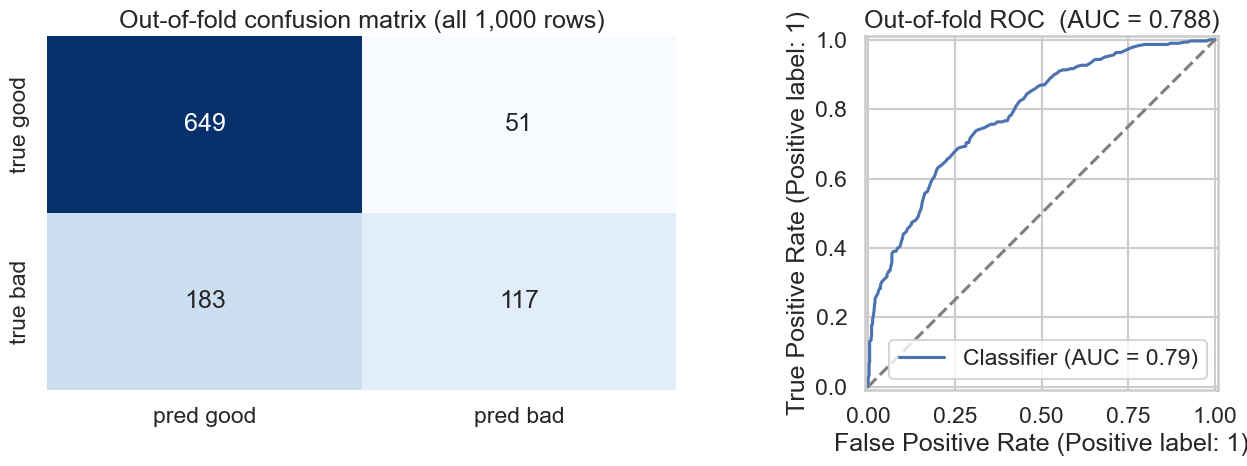

In [6]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, roc_auc_score, RocCurveDisplay

cv = StratifiedKFold(5, shuffle=True, random_state=RS)
# Each row's probability comes from a fold where that row was in the TEST set.
oof_proba = cross_val_predict(clf_pipeline(), X, y, cv=cv, method="predict_proba")[:, 1]
oof_pred = (oof_proba >= 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y, oof_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["pred good", "pred bad"], yticklabels=["true good", "true bad"])
axes[0].set_title("Out-of-fold confusion matrix (all 1,000 rows)")
RocCurveDisplay.from_predictions(y, oof_proba, ax=axes[1], color="#4C72B0")
axes[1].plot([0, 1], [0, 1], "--", color="gray")
axes[1].set_title(f"Out-of-fold ROC  (AUC = {roc_auc_score(y, oof_proba):.3f})")
plt.tight_layout(); plt.show()

### How to read this — and one sharp warning

- Every prediction above was made on a row **held out** of the model that scored it, so this
  confusion matrix and ROC are honest, full-coverage summaries — great for choosing a decision
  threshold (see the supervised repo's threshold notebook).
- **Warning (a real sklearn gotcha):** `cross_val_predict` is for *visualizing/using
  predictions*, **not** for estimating performance. Averaging a metric over its pooled
  predictions is **not** the same as `cross_val_score` and can be biased, because the pooled
  predictions come from different models. For a performance *number*, use `cross_val_score` /
  `cross_validate`; use `cross_val_predict` to get predictions to *inspect or reuse*.

## Section 6 — Cross-validation for a regression target

Everything so far scored classification. CV is identical for **regression** — you just swap the
metric. Regression has no classes to stratify, so plain `KFold` is the base tool. We use
**Bike Sharing** and report three metrics at once with `cross_validate`.

> ⚠️ Bike Sharing is **time-ordered**, and shuffling time is a form of leakage. We shuffle here
> **only** to demonstrate regression metrics on a familiar footing — Notebook 03 does time
> **properly** with `TimeSeriesSplit`. Treat this section as "regression metrics," not "the
> right way to validate this dataset."

Bike Sharing — 5-fold regression CV (metric per fold):
  R^2  : 0.947 +/- 0.003
  RMSE : 41.6 rentals/hour
  MAE  : 26.2 rentals/hour


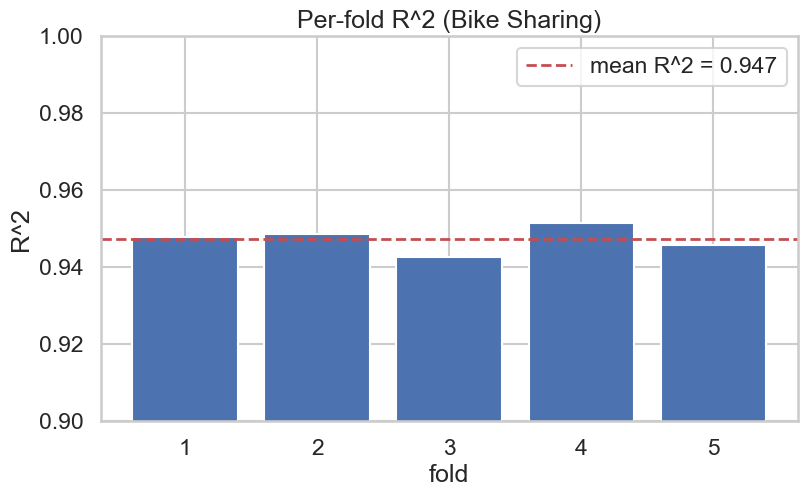

In [7]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import cross_validate

Xb, yb = load_bike()
num_b, cat_b = feature_types(Xb)
reg = Pipeline([
    ("pre", ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), cat_b)],
                              remainder="passthrough")),
    ("gbr", HistGradientBoostingRegressor(random_state=RS)),
])

res = cross_validate(reg, Xb, yb, cv=KFold(5, shuffle=True, random_state=RS),
                     scoring=["r2", "neg_root_mean_squared_error", "neg_mean_absolute_error"])

print("Bike Sharing — 5-fold regression CV (metric per fold):")
print(f"  R^2  : {res['test_r2'].mean():.3f} +/- {res['test_r2'].std():.3f}")
print(f"  RMSE : {-res['test_neg_root_mean_squared_error'].mean():.1f} rentals/hour")
print(f"  MAE  : {-res['test_neg_mean_absolute_error'].mean():.1f} rentals/hour")

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(range(1, 6), res["test_r2"], color="#4C72B0", edgecolor="white")
ax.axhline(res["test_r2"].mean(), ls="--", color="#C44E52", lw=2,
           label=f"mean R^2 = {res['test_r2'].mean():.3f}")
ax.set(title="Per-fold R^2 (Bike Sharing)", xlabel="fold", ylabel="R^2", ylim=(0.9, 1.0))
ax.legend(); plt.show()

### How to read this

- **`neg_root_mean_squared_error`?** scikit-learn maximizes scores, so "lower error is better"
  is expressed as a *negative* number you flip back with a minus sign. RMSE and MAE are in the
  target's own units (rentals/hour) — directly interpretable.
- Report **R² *and* an error in real units**: R² says "explains 95% of variance," RMSE/MAE say
  "typically off by ~26–42 bikes." Stakeholders understand the second one.
- The mechanics (`cross_validate`, multiple `scoring` metrics, per-fold arrays) are identical
  for any estimator — classification or regression.

## Key takeaways

1. **`StratifiedKFold` is the classification default** — it removes a silent failure mode for
   free. Plain `KFold` is for regression or already-shuffled, class-free data.
2. **`RepeatedStratifiedKFold`** pins down the mean when a decision rides on small differences.
3. **`ShuffleSplit`** decouples test size from the number of rounds; looser, use deliberately.
4. **LOOCV is just extreme K** — near-unbiased, high-variance, expensive, and usually agrees
   with 10-fold. Save it for tiny data.
5. **`cross_val_predict`** gives out-of-fold predictions (for stacking/calibration/plots) — but
   never use it as a performance *estimate*.
6. **Regression CV is the same procedure, different metric** — report R² *and* an error in real
   units.

### Next → **03 — Grouped & Time-Aware CV**
So far we assumed rows are independent and shuffleable. They often aren't: the same patient
appears in many rows, or the data has a time arrow you must not cross. Next we handle groups
(`GroupKFold`, `LeaveOneGroupOut`) and time (`TimeSeriesSplit`, purged & embargoed CV).